In [1]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1/src')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 180, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 180 (delta 13), reused 9 (delta 9), pack-reused 159 (from 1)
Receiving objects: 100% (180/180), 4.34 MiB | 20.31 MiB/s, done.
Resolving deltas: 100% (75/75), done.


In [10]:
from synthetic_dataset import SyntheticEllipseDataset
from resunet import ResUNet
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
dataset = SyntheticEllipseDataset(num_samples=512)
train_dataset, test_dataset = random_split(dataset, [0.8, 0.2])

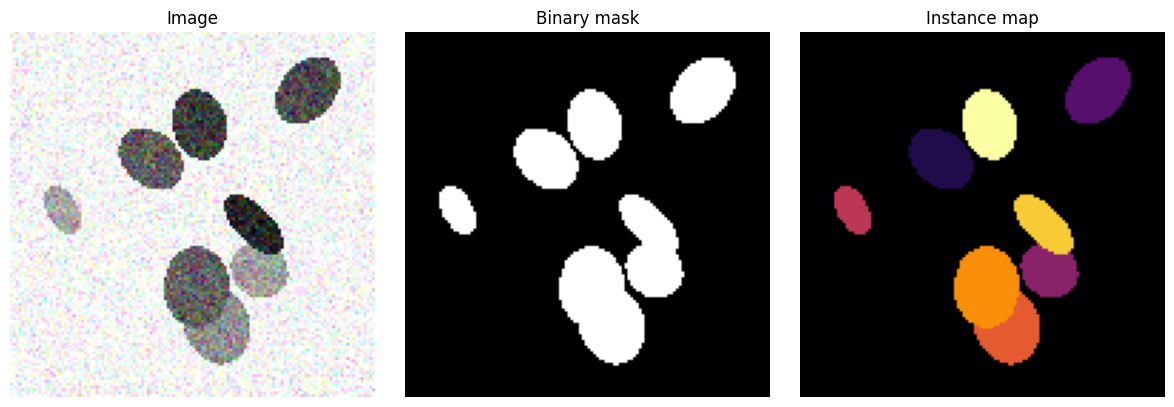

In [5]:
# Visualizando uma amostra dos dados

image, mask, instance_map = train_dataset[0]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))

axes[0].imshow(image.squeeze().permute(1,2,0), cmap='gray')
axes[0].set_title('Image')
axes[0].axis('off')

axes[1].imshow(mask.squeeze(), cmap='gray')
axes[1].set_title('Binary mask')
axes[1].axis('off')

axes[2].imshow(instance_map.squeeze(), cmap='inferno')
axes[2].set_title('Instance map')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [9]:
# Treinando a ResUNet no dataset sintético

model = ResUNet(3, 1).to(device)

loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(10):
    for batch, (image, mask, _) in enumerate(loader):
        image, mask = image.to(device), mask.to(device)

        y_hat = model(image).squeeze(1)
        loss = loss_fn(y_hat, mask)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.6433013081550598
0/5 - loss=0.5025298595428467
0/10 - loss=0.4135875105857849
0/15 - loss=0.3478150963783264
0/20 - loss=0.29221487045288086
0/25 - loss=0.2545364499092102
1/0 - loss=0.25586891174316406
1/5 - loss=0.20275059342384338
1/10 - loss=0.17623870074748993
1/15 - loss=0.15116363763809204
1/20 - loss=0.14039647579193115
1/25 - loss=0.1325932741165161
2/0 - loss=0.10452347993850708
2/5 - loss=0.10886700451374054
2/10 - loss=0.08698788285255432
2/15 - loss=0.08582407236099243
2/20 - loss=0.06863785535097122
2/25 - loss=0.060280658304691315
3/0 - loss=0.05933624505996704
3/5 - loss=0.06361696124076843
3/10 - loss=0.05023444443941116
3/15 - loss=0.04669123888015747
3/20 - loss=0.04621501266956329
3/25 - loss=0.03990475833415985
4/0 - loss=0.04297316446900368
4/5 - loss=0.04917922243475914
4/10 - loss=0.03368062153458595
4/15 - loss=0.03028715029358864
4/20 - loss=0.029952628538012505
4/25 - loss=0.025791212916374207
5/0 - loss=0.039659980684518814
5/5 - loss=0.03611013

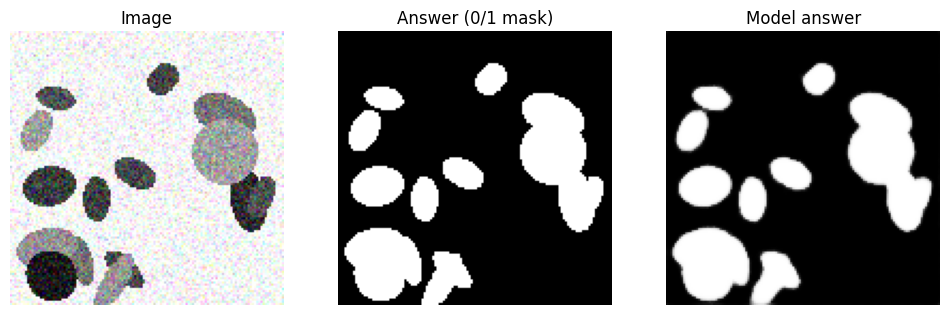

In [14]:
# Verificando a saída do modelo

model.eval()

for img, mask, _ in DataLoader(test_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")

    plt.show()

    break